In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [3]:
import pandas as pd 
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from collections import defaultdict

In [4]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')

/tmp/ipykernel_1025228/3040835416.py:1: DtypeWarning: Columns (333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,376,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')


In [5]:
import pandas as pd
from scipy.stats import ttest_ind
rows = []
for _, row in data.iterrows():
    genes = [g.strip() for g in str(row['mutated_genes']).split(',')]#replace('&', ',').split(',')]
    for gene in genes:
        new_row = row.copy()
        new_row['mutated_genes'] = gene
        rows.append(new_row)
data = pd.DataFrame(rows).reset_index(drop=True)

data_clean = data.dropna(subset=['y2_slope', 'mutated_genes', 'plate', 'light_regime'])

genes_to_test = (
    data_clean[data_clean['mutated_genes'] != 'WT']
    [['light_regime', 'mutated_genes']]
    .drop_duplicates()
    .rename(columns={'mutated_genes': 'gene'})
)

results = []

for _, row in genes_to_test.iterrows():
    regime = row['light_regime']
    gene = row['gene']
    
    plates_with_gene = data_clean[
        (data_clean['light_regime'] == regime) &
        (data_clean['mutated_genes'] == gene)
    ]['plate'].unique()
    
    subset = data_clean[
        (data_clean['light_regime'] == regime) &
        (data_clean['plate'].isin(plates_with_gene)) &
        (data_clean['mutated_genes'].isin(['WT', gene]))
    ]
    
    mutant_vals = subset[subset['mutated_genes'] == gene]['y2_slope']
    wt_vals = subset[subset['mutated_genes'] == 'WT']['y2_slope']
    
    if len(mutant_vals) > 1 and len(wt_vals) > 1:
        stat, pval = ttest_ind(mutant_vals, wt_vals, equal_var=False)
    else:
        stat, pval = None, None

    results.append({
        'light_regime': regime,
        'gene': gene,
        'mutant_mean': mutant_vals.mean() if len(mutant_vals) > 0 else None,
        'wt_mean': wt_vals.mean() if len(wt_vals) > 0 else None,
        'p_value': pval,
        'n_mutant': len(mutant_vals),
        'n_wt': len(wt_vals)
    }) 
results_df = pd.DataFrame(results)
print(results_df)

     light_regime                           gene  mutant_mean   wt_mean  \
0          20h_HL  Cre06.g278194 & Cre06.g278195    -0.007143 -0.004045   
1          20h_HL                  Cre06.g278194    -0.006652 -0.004063   
2          20h_HL                  Cre02.g105350    -0.005156 -0.004113   
3          20h_HL                  Cre02.g095135    -0.004853 -0.004045   
4          20h_HL                  Cre01.g036050    -0.004251 -0.004045   
...           ...                            ...          ...       ...   
4782      30s-30s                  Cre07.g321000    -0.001031 -0.001970   
4783      30s-30s                  Cre12.g542200    -0.001858 -0.001970   
4784      30s-30s                  Cre04.g214097    -0.000146 -0.001970   
4785      30s-30s                  Cre17.g716750    -0.000474 -0.001970   
4786      30s-30s                  Cre16.g664850    -0.003111 -0.001970   

       p_value  n_mutant  n_wt  
0     0.014666         3    20  
1     0.000081         9    38  


In [6]:
results_df = results_df.sort_values('p_value')
results_df['rank'] = np.arange(1, len(results_df) + 1)
results_df['BH_threshold'] = (results_df['rank'] / len(results_df)) * 0.05
results_df['significant'] = results_df['p_value'] < results_df['BH_threshold']
significant_data = results_df[results_df['significant']]


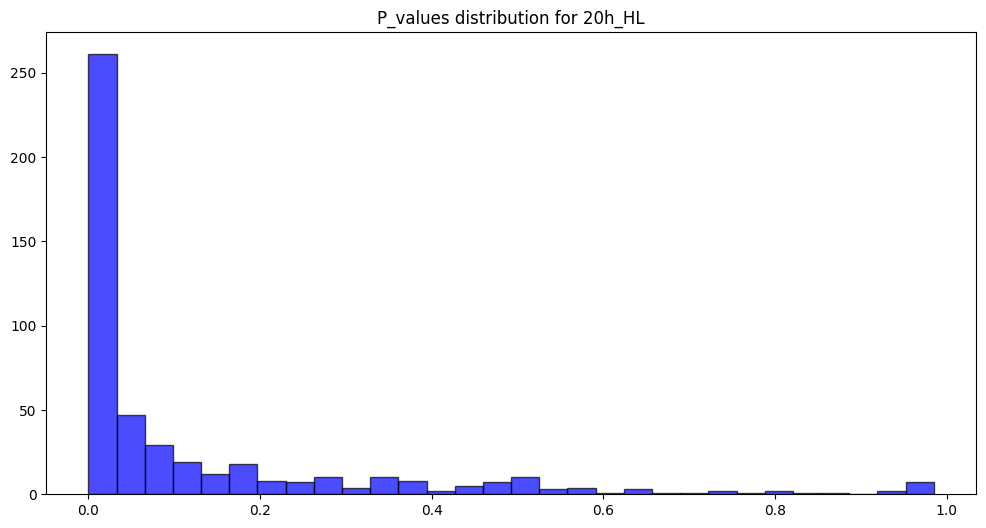

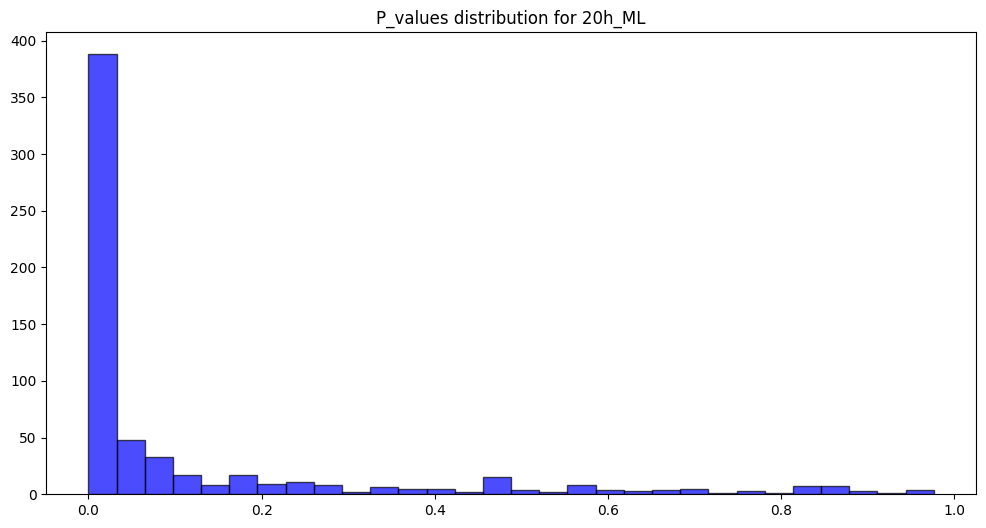

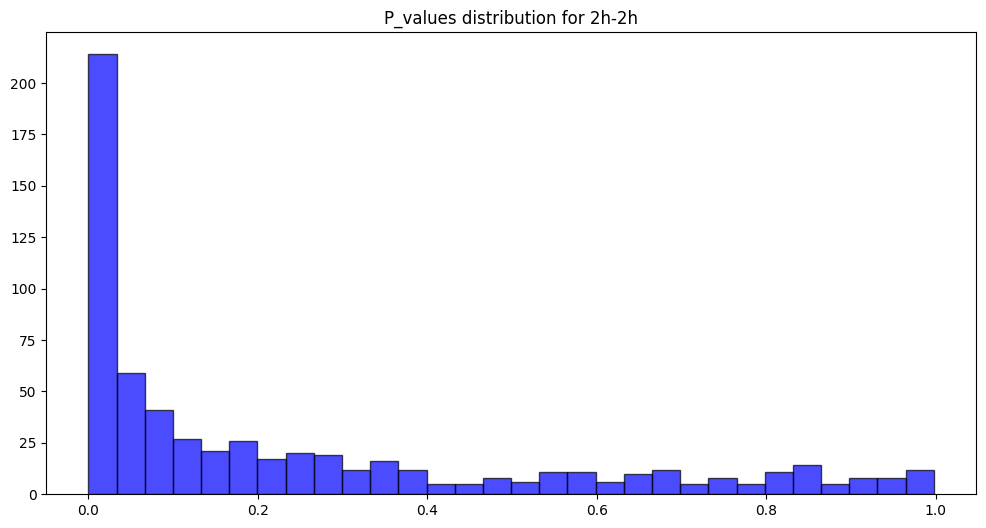

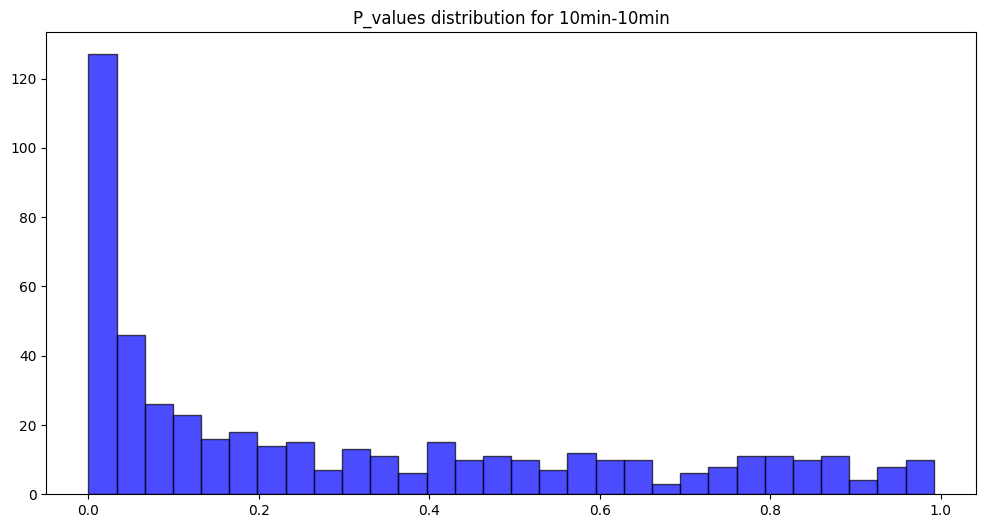

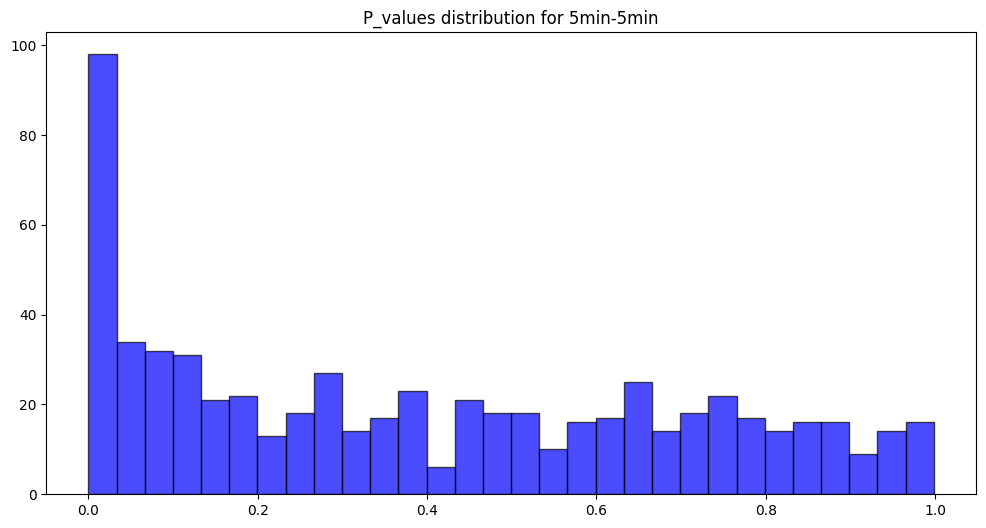

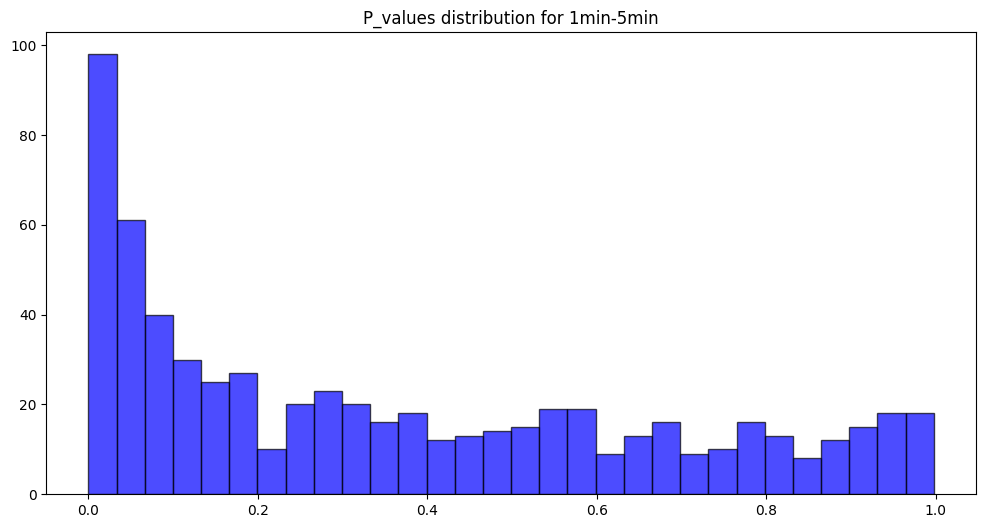

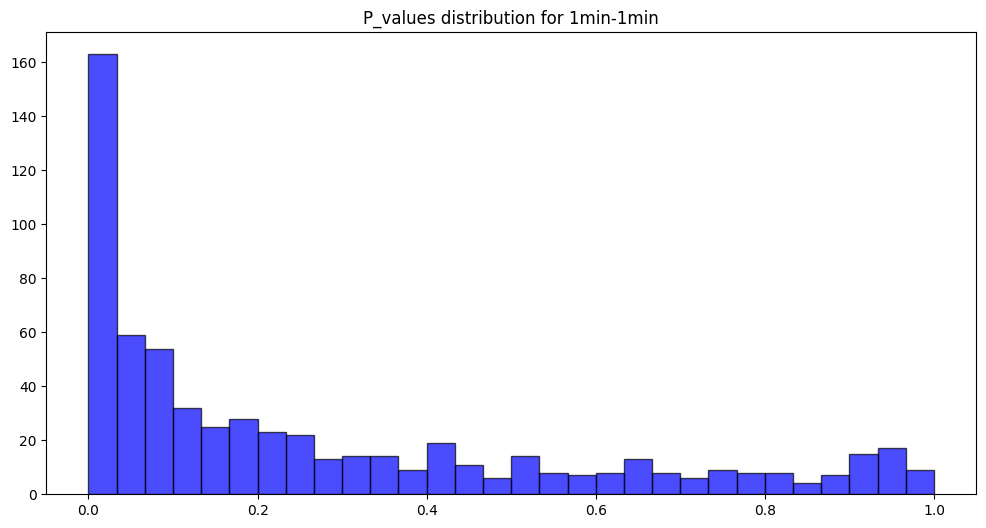

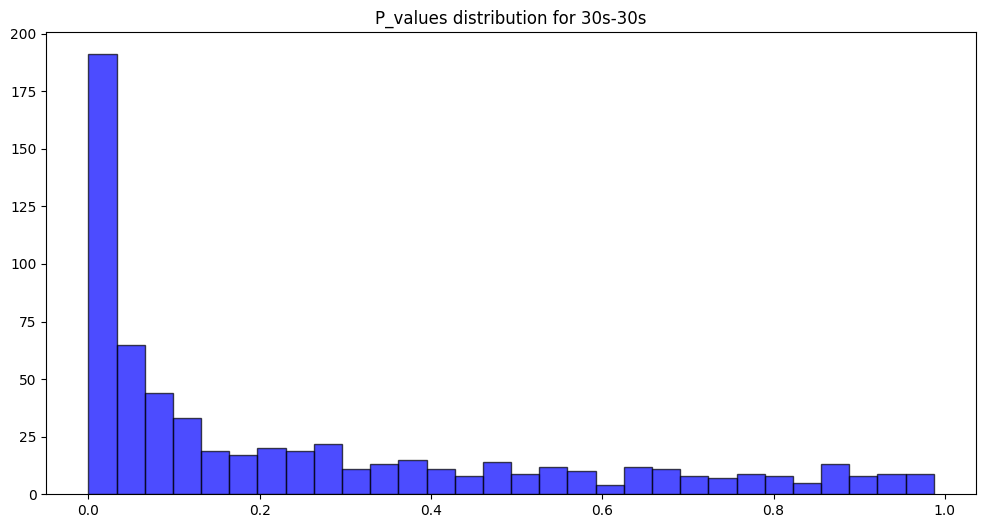

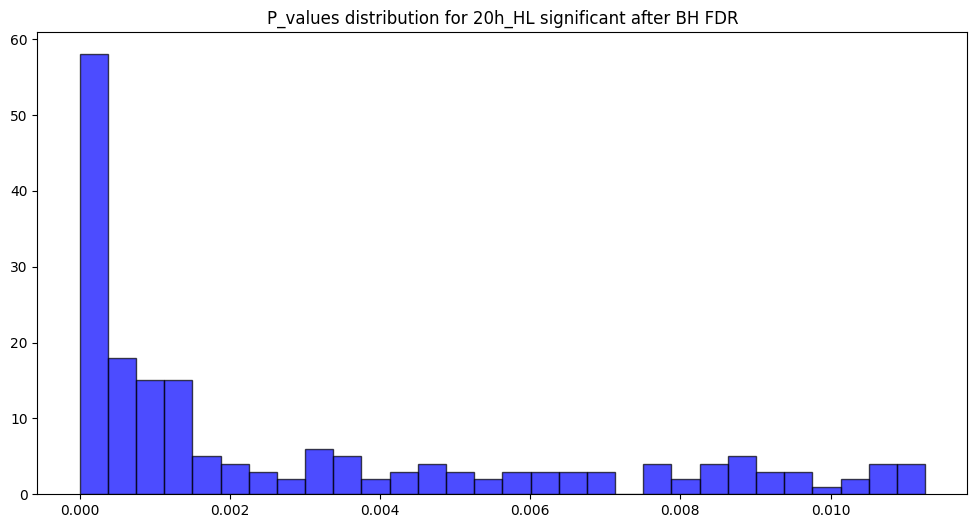

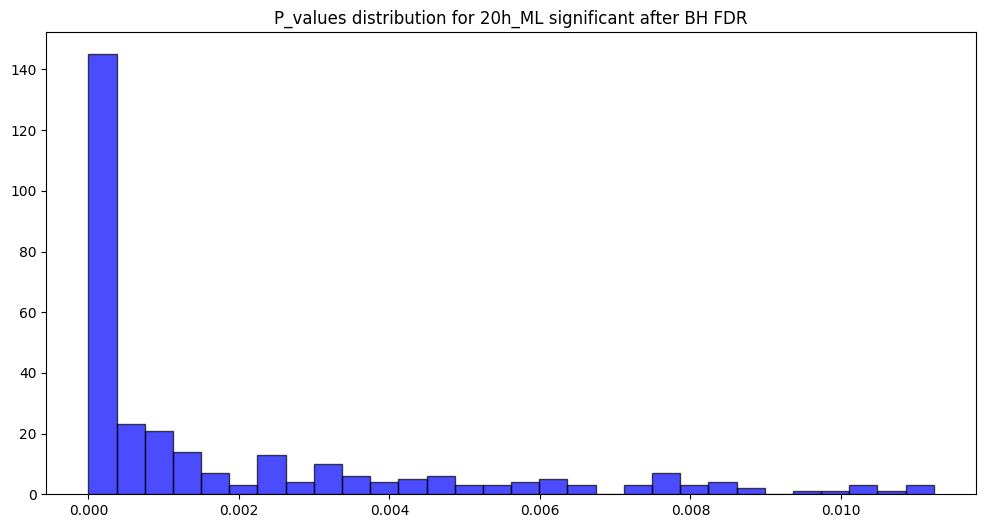

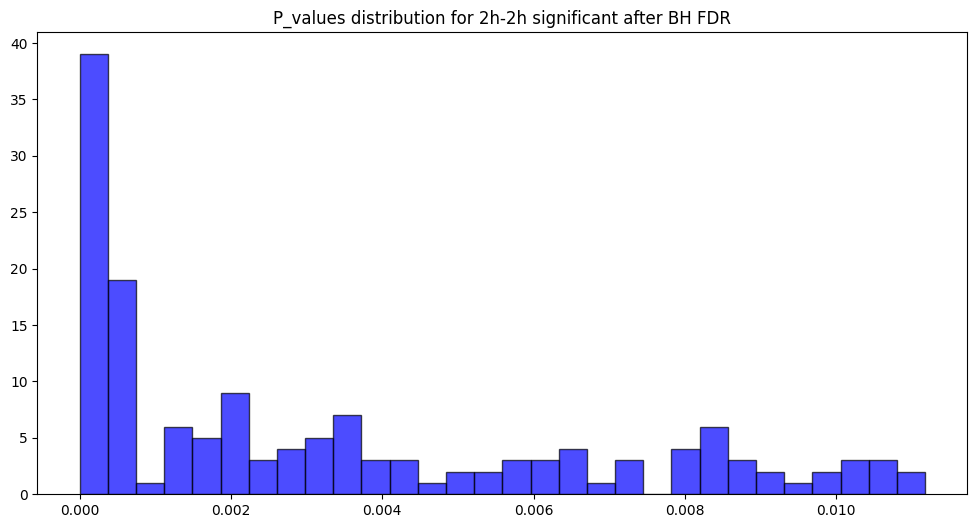

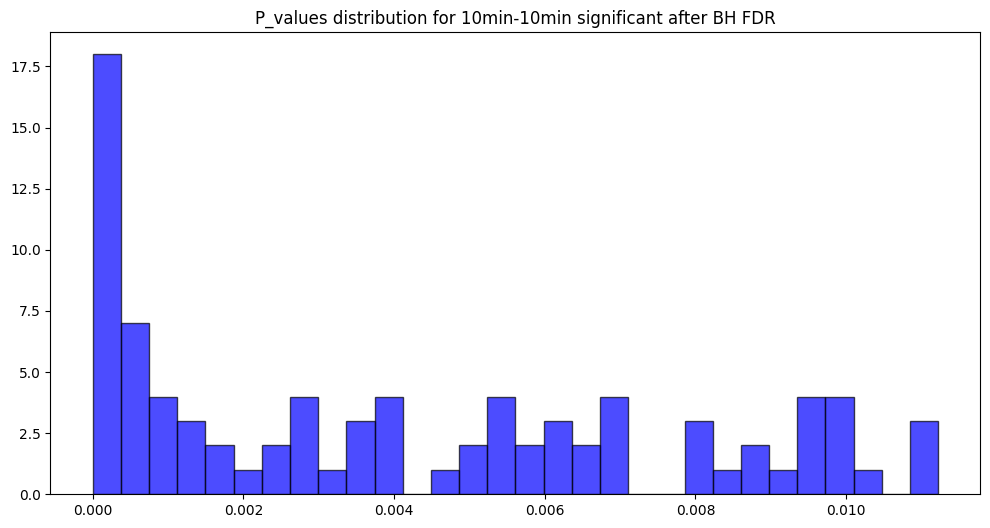

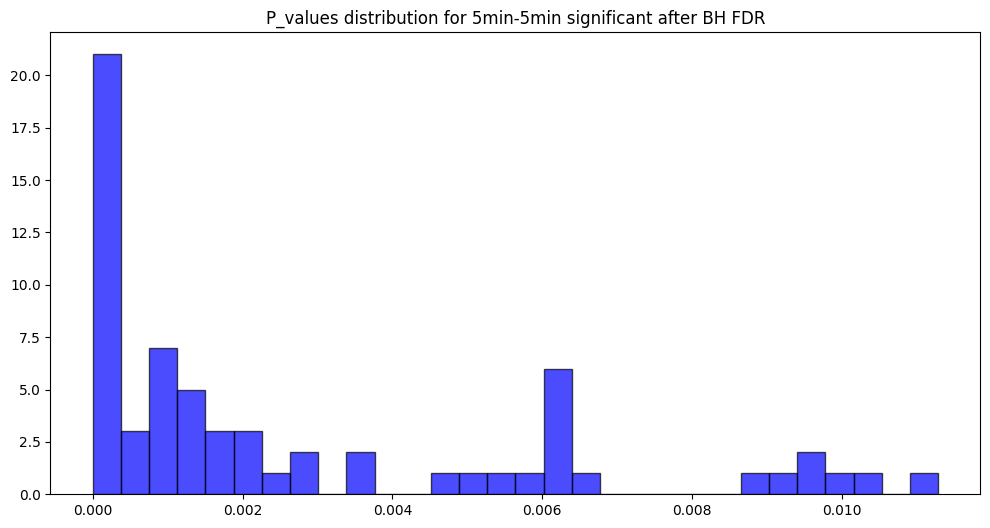

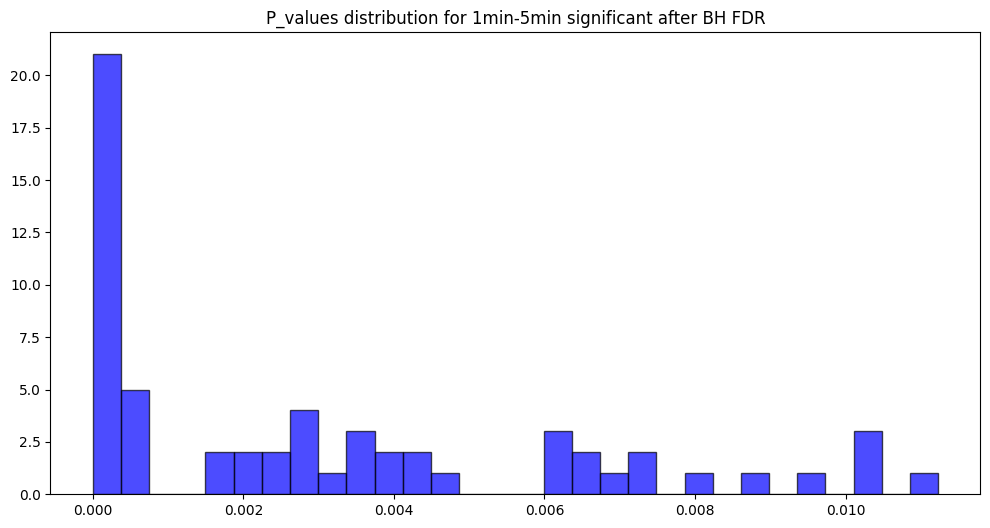

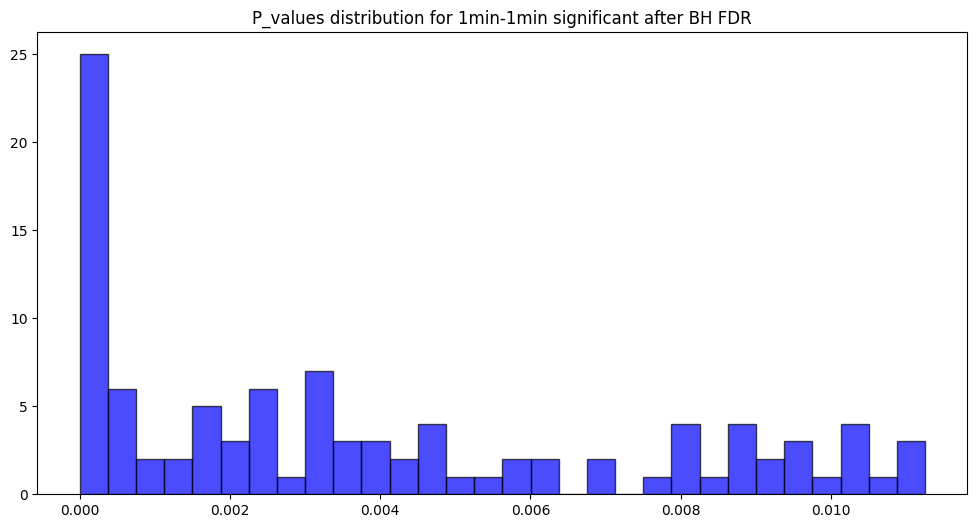

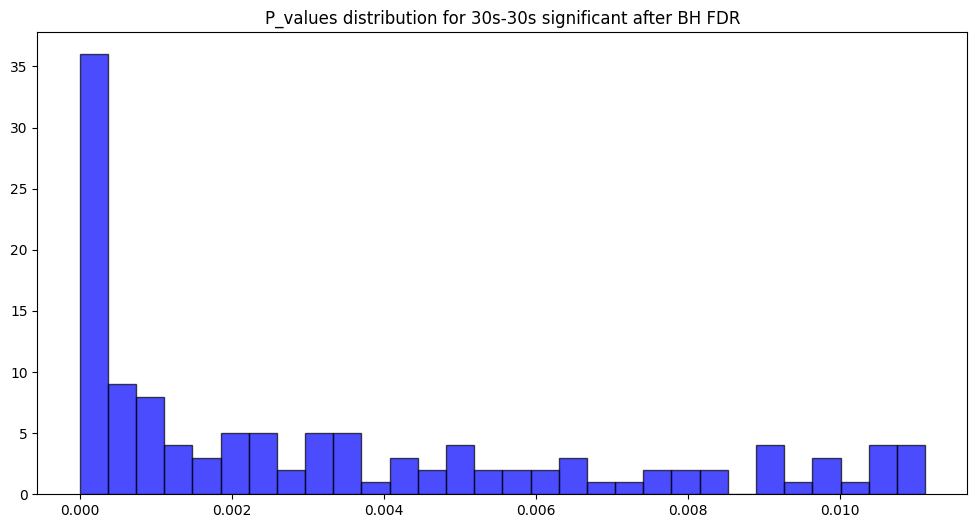

In [7]:
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
for light in light_regimes:
    subset = results_df[results_df['light_regime'] == light]
    plt.figure(figsize=(12,6))
    plt.hist(subset['p_value'], bins=30, alpha=0.7,color='blue',edgecolor='black')
    plt.title(f'P_values distribution for {light}')
for light in light_regimes:
    subset = significant_data[significant_data['light_regime'] == light]
    plt.figure(figsize=(12,6))
    plt.hist(subset['p_value'], bins=30, alpha=0.7,color='blue',edgecolor='black')
    plt.title(f'P_values distribution for {light} significant after BH FDR')


In [8]:
print(len(results_df[results_df['p_value'] < 0.05]['gene'].unique()))
print(len(significant_data['gene'].unique()))
print(len(data['mutated_genes'].unique()))

601
504
640


### Slope cluster from the box plot (+1 or -1 or 0 around WT confidence interval)

In [10]:
result = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff_slope_cluster_y2_p_valzscore.csv')

In [11]:
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
set_of_genes = set()
overall_count = 0
for light in light_regimes:
    subset = result[result['light_regime'] == light]
    light_count = 0
    for gene in subset['mutated_genes'].unique():
        subset_gene = subset[subset['mutated_genes'] == gene]
        if len(set(subset_gene['slope_cluster_y2'])) == 1:
            #print(f"Gene {gene} is consistent across all mutants in cluster :{set(subset_gene['slope_cluster_y2'])}")
            if set(subset_gene['slope_cluster_y2']) != {0}:
                set_of_genes.add(gene)
                light_count+=1
    print(f"Number of consistent genes for {light} : {light_count}")
    overall_count += light_count
print(f"Total number of consistent outlier genes across all light regimes: {overall_count}")
print(f"Total number of unique consistent outlier genes across all light regimes: {len(set_of_genes)}")

Number of consistent genes for 20h_HL : 73
Number of consistent genes for 20h_ML : 70
Number of consistent genes for 2h-2h : 28
Number of consistent genes for 10min-10min : 33
Number of consistent genes for 5min-5min : 90
Number of consistent genes for 1min-5min : 43
Number of consistent genes for 1min-1min : 126
Number of consistent genes for 30s-30s : 113
Total number of consistent outlier genes across all light regimes: 576
Total number of unique consistent outlier genes across all light regimes: 261


### venn diagram

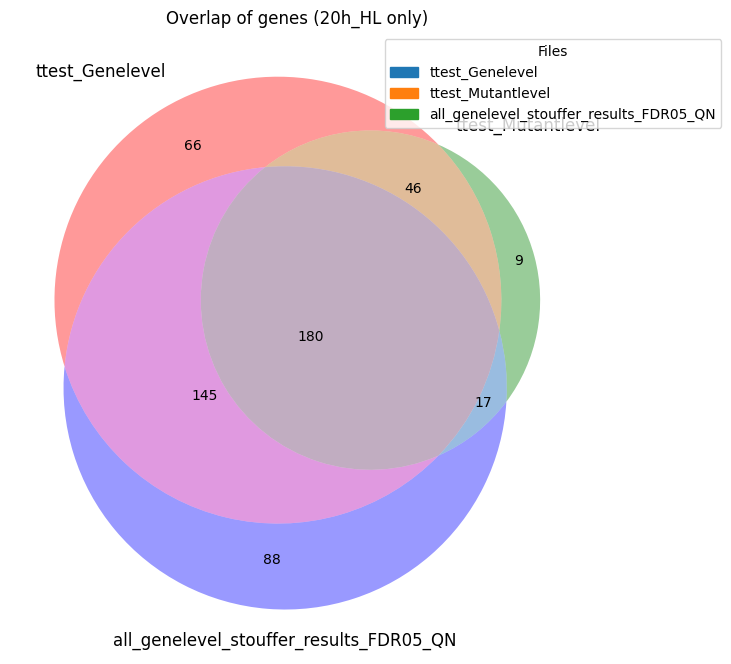

Total unique genes across selected files: 551
Genes common to all selected files: 180
Common genes: ['Cre01.g000650', 'Cre01.g003950', 'Cre01.g004124', 'Cre01.g004950', 'Cre01.g012650,Cre17.g724450', 'Cre01.g019550', 'Cre01.g019850', 'Cre01.g022900', 'Cre01.g025400', 'Cre01.g030700', 'Cre01.g034150', 'Cre01.g037100', 'Cre01.g038151', 'Cre01.g038900', 'Cre01.g040950', 'Cre01.g043250', 'Cre01.g045150', 'Cre02.g080900', 'Cre02.g089237', 'Cre02.g090100', 'Cre02.g093550', 'Cre02.g095058', 'Cre02.g095063', 'Cre02.g095137', 'Cre02.g105150,Cre16.g688638', 'Cre02.g115600', 'Cre02.g119050', 'Cre02.g119100', 'Cre02.g146300', 'Cre03.g153400', 'Cre03.g154651', 'Cre03.g159150', 'Cre03.g159200,Cre01.g019850', 'Cre03.g160350', 'Cre03.g169800', 'Cre03.g171650', 'Cre03.g176961,Cre14.g613652', 'Cre03.g185500', 'Cre03.g192450', 'Cre03.g207351', 'Cre04.g212550', 'Cre04.g213652', 'Cre04.g215150', 'Cre04.g216050', 'Cre04.g218500', 'Cre04.g219700', 'Cre04.g222600', 'Cre04.g224700', 'Cre04.g229163,Cre09.g39300

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import glob
import os
from matplotlib.patches import Patch

# Set your folder path
folder = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes3"  # CHANGE THIS
files = glob.glob(os.path.join(folder, "*.csv"))

# Filter for 20h_HL and collect gene sets
gene_sets = {}
for f in files:
    try:
        df = pd.read_csv(f)
        df = df[df['light_regime'] == "30s-30s"]
        genes = set(df['mutated_genes'].dropna())
        if len(genes) == 0:
            continue
        label = os.path.basename(f).replace(".csv", "")
        gene_sets[label] = genes
    except Exception as e:
        print(f"Error reading {f}: {e}")

# Limit to 2 or 3 sets
selected_labels = list(gene_sets.keys())[:3]
selected_sets = [gene_sets[label] for label in selected_labels]

# Plot
plt.figure(figsize=(7, 7))
if len(selected_sets) == 2:
    v = venn2(selected_sets, set_labels=selected_labels)
elif len(selected_sets) == 3:
    v = venn3(selected_sets, set_labels=selected_labels)
else:
    raise ValueError("Need 2 or 3 files with 20h_HL to plot a Venn diagram.")

# Manually create legend using patch colors
patches = []
for i, label in enumerate(selected_labels):
    # Access the circle patch (A, B, C)
    key = ['10', '01', '11', '100', '010', '001', '110', '101', '011', '111'][i]
    region = [p for p in v.patches if p and p.get_label() == label]
    if region:
        color = region[0].get_facecolor()
    else:
        # fallback: just pull a default color
        color = plt.cm.tab10(i)
    patches.append(Patch(color=color, label=label))

plt.legend(handles=patches, title="Files", loc="upper right", bbox_to_anchor=(1.25, 1))
plt.title("Overlap of genes (20h_HL only)")
plt.tight_layout()
plt.show()

# Print stats
all_genes = set.union(*selected_sets)
common_genes = set.intersection(*selected_sets)

print(f"Total unique genes across selected files: {len(all_genes)}")
print(f"Genes common to all selected files: {len(common_genes)}")
print("Common genes:", sorted(common_genes))


### Key genes 